# Unit 3：EEG 中的伪迹识别

## 目标
- 认识 EEG 中的常见伪迹类型
- 理解每种伪迹的时域/频域/空间特征
- 学会肉眼 + 工具识别伪迹

> ⚠️ 本数据集的 EEG 通道名为 `EEG 001`、`EEG 002` 等数字编号。
> `EEG 001`/`EEG 002` 大致对应前额 Fp1/Fp2 位置。


### 3.1 加载 EEG 数据


In [ ]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt

data_dir = os.path.abspath("./../datasets")
os.makedirs(data_dir, exist_ok=True)
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)

sample_data_dir = mne.datasets.sample.data_path()
raw_fname = sample_data_dir / 'MEG' / 'sample' / 'sample_audvis_raw.fif'

raw = mne.io.read_raw_fif(raw_fname, preload=True)
raw.pick(['eeg']) # pick(['eeg']) 不会过滤 info['dig']

# raw.info['dig'] 返回的是 所有通道的 digitization points
dig = raw.info['dig']
# 直接使用文件内自带的电极位置（不需要外部 montage）
# 验证 montage 是否已在位
montage = raw.get_montage()
if montage is None:
    print("⚠️ 无内置 montage，需要手动设置")
else:
    print(f"✅ 内置 montage 已就绪，{len(montage.ch_names)} 个电极")

print("有了 montage（即每个通道都有 3D 坐标）后，MNE 能解锁一大类 空间可视化 功能。")

Opening raw data file d:\AI\qwenpaw\eeg_ica_learning\datasets\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
✅ 内置 montage 已就绪，60 个电极
有了 montage（即每个通道都有 3D 坐标）后，MNE 能解锁一大类 空间可视化 功能。


### 3.2 伪迹类型一：眨眼（Eye Blink）

**特征：**
- 时域：大振幅尖峰（100-200 μV），持续 200-400 ms
- 空间：前额通道（`EEG 001`/`EEG 002`）最强，向后递减
- 频域：低频为主（< 5 Hz）


In [7]:
# 自动找出眨眼候选：在前额通道上找异常大振幅的时间点
fp1_data = raw.get_data(picks='EEG 001')[0]
fp2_data = raw.get_data(picks='EEG 002')[0]

# 找振幅超过 80 μV 的点作为眨眼候选
blink_threshold = 80e-6
blink_mask = (np.abs(fp1_data) > blink_threshold) | (np.abs(fp2_data) > blink_threshold)
print(blink_mask.shape)
print(sum(blink_mask))


(166800,)
17448


In [ ]:

# 找出连续的眨眼段
blink_events = []
in_blink = False
for i, v in enumerate(blink_mask):
    if v and not in_blink:
        start = i
        in_blink = True
    elif not v and in_blink:
        blink_events.append((start / raw.info['sfreq'], i / raw.info['sfreq']))
        in_blink = False

# blink_events = [(0.415, 0.416), (0.428, 0.623), ...]

print(f"检测到 {len(blink_events)} 个可能的眨眼事件")
print(f"前 5 个眨眼的时间位置:")
for i, (start, end) in enumerate(blink_events[:5]):
    print(f"  #{i+1}: {start:.3f}s - {end:.3f}s (持续 {end-start:.3f}s)")


检测到 761 个可能的眨眼事件
前 5 个眨眼的时间位置:
  #1: 0.415s - 0.416s (持续 0.002s)
  #2: 0.428s - 0.623s (持续 0.195s)
  #3: 0.624s - 0.626s (持续 0.002s)
  #4: 2.246s - 2.249s (持续 0.003s)
  #5: 2.254s - 2.258s (持续 0.003s)


In [22]:
# 放大看第一个眨眼事件
if blink_events:
    t0 = blink_events[1][0]  # 取第二个（第一个可能在边缘）
    # 截取 眨眼前 1 秒 → 眨眼后 3 秒 共约 4 秒的片段,构造一个围绕眨眼的 4 秒观察窗口
    raw_cropped = raw.copy().crop(tmax=t0 + 3).crop(tmin=max(0, t0 - 1))
    
    # 画前 10 个通道
    raw_cropped.plot(
        n_channels=20,  # 显示的通道数量
        scalings=dict(eeg=100e-6),  # EEG通道的缩放比例（100微伏）
        title=f'Blink Artifact Example (around t={t0:.3f}s)',  # Chart title
        duration=4  # 显示的时间窗口长度（秒）
    )
    print("✅ 眨眼伪迹示例已显示")


✅ 眨眼伪迹示例已显示


### 3.3 伪迹类型二：眼动（Eye Movement / EOG）

**特征：**
- 水平眼动：F7/F8 位置的通道有阶梯状偏移
- 垂直眼动：Fp1/Fp2 位置的通道有缓慢漂移
- 频率：< 4 Hz，持续数百毫秒


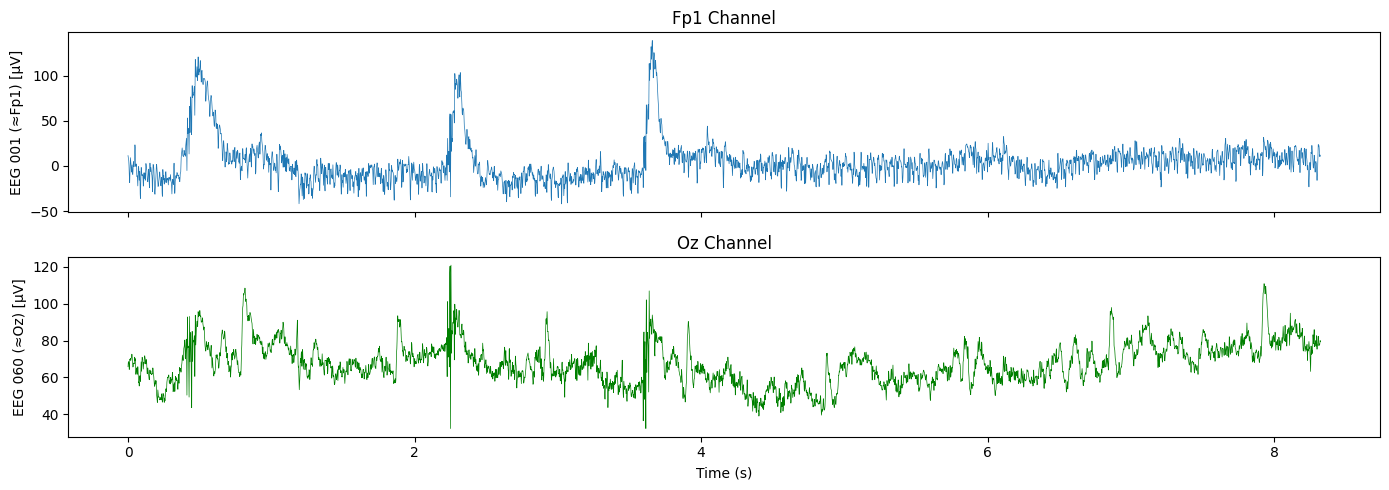

→ Fp1 有明显低频漂移（眼动），而 Oz 相对干净。这就是空间特异性。


In [24]:
# 画前额通道 vs 枕部通道对比
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

fp1_data = raw.get_data(picks='EEG 001')[0] # shape: (166800,)
axes[0].plot(raw.times[:5000], fp1_data[:5000]*1e6, linewidth=0.5)
axes[0].set_ylabel('EEG 001 (≈Fp1) [μV]')
axes[0].set_title('Fp1 Channel') # 前额通道 — 注意低频漂移（眼动伪迹）

# 枕部通道作为对照
oz_data = raw.get_data(picks='EEG 060')[0] # shape: (166800,)
axes[1].plot(raw.times[:5000], oz_data[:5000]*1e6, linewidth=0.5, color='green')
axes[1].set_ylabel('EEG 060 (≈Oz) [μV]')
axes[1].set_title('Oz Channel') # 枕部通道 — 相对干净，眼动影响小
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()
print("→ Fp1 有明显低频漂移（眼动），而 Oz 相对干净。这就是空间特异性。")


### 3.4 伪迹类型三：心电（ECG / Cardiac）

**特征：**
- 周期性尖峰，间隔 ≈ 心率周期（0.6-1.0 秒）
- 振幅 10-100 μV
- 在所有通道上出现，但振幅/极性因通道而异


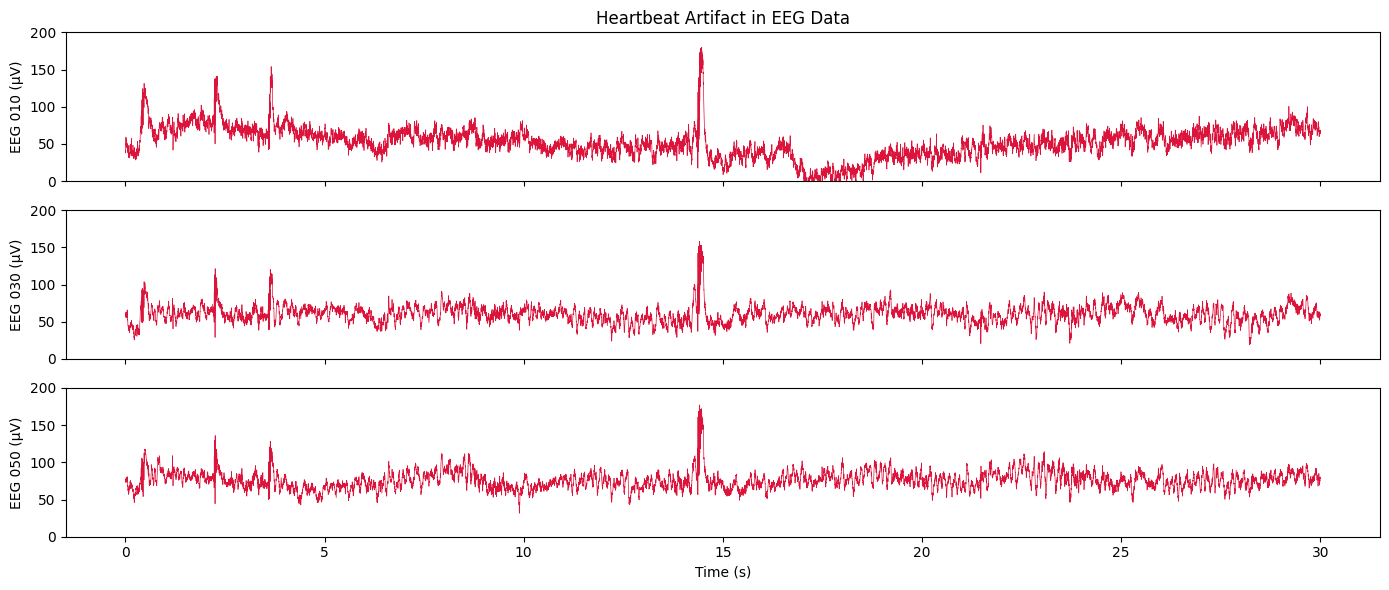

心跳伪迹线索：规律尖峰，间隔约 0.6-1s，多个通道同时出现。


In [37]:
# 在多个通道上找周期性尖峰
data_30s = raw.get_data()[:, :int(30 * raw.info['sfreq'])] # shape:(60,18018)
times_30s = raw.times[:int(30 * raw.info['sfreq'])] # shape:(18018,)

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
for i, ch_name in enumerate(['EEG 010', 'EEG 030', 'EEG 050']):
    ch_idx = raw.ch_names.index(ch_name)
    axes[i].plot(times_30s, data_30s[ch_idx]*1e6, linewidth=0.5 ,color='crimson')
    axes[i].set_ylabel(f'{ch_name} (μV)')
    axes[i].set_ylim(0, 200)
axes[0].set_title('Heartbeat Artifact in EEG Data') # 在不同通道上寻找规律出现的尖峰（心跳伪迹）
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()
print("心跳伪迹线索：规律尖峰，间隔约 0.6-1s，多个通道同时出现。")


### 3.5 伪迹类型四：肌肉伪迹（EMG）

**特征：**
- 高频（20-300 Hz）不规则噪声
- 振幅突然增大
- 常见于颞部通道（受试者咬牙/紧张时）


Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).
肌电伪迹线索：PSD 在 20-100 Hz 的异常功率。


d:\AI\qwenpaw\eeg_ica_learning\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


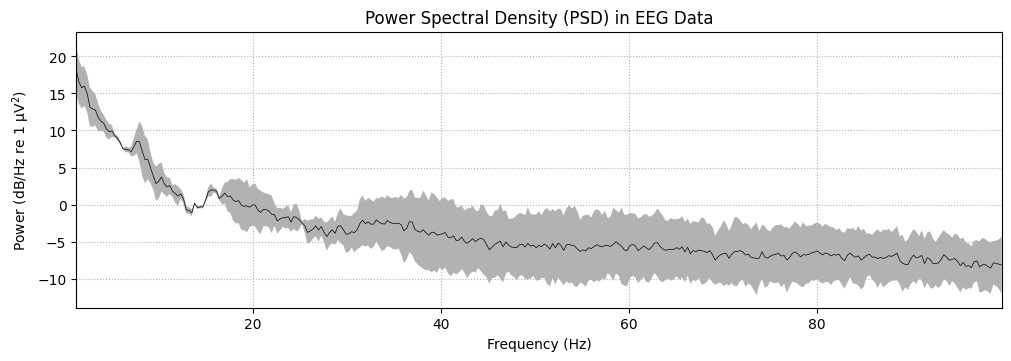

In [45]:
# 对比低频段和高频段的 PSD
raw_psd = raw.compute_psd(fmin=1, fmax=100, picks=['EEG 001', 'EEG 030'])
fig = raw_psd.plot(average=True, spatial_colors=False)
plt.title('Power Spectral Density (PSD) in EEG Data') # 功率谱密度 — 高频段（>30Hz）异常隆起提示肌电伪迹
print("肌电伪迹线索：PSD 在 20-100 Hz 的异常功率。")


### 3.6 伪迹总结表

| 伪迹 | 时域 | 频域 | 空间 | 振幅 |
|------|------|------|------|------|
| 眨眼 | 尖峰 200-400ms | < 5 Hz | 前额最强 | 100-200 μV |
| 眼动 | 阶梯/漂移 | < 4 Hz | F7/F8, Fp1/Fp2 | 50-100 μV |
| 心电 | 周期尖峰 ~1s | 5-20 Hz 有峰 | 全头，振幅各异 | 10-100 μV |
| 肌电 | 高频不规则 | 20-300 Hz | 颞部最强 | 变化大 |

### 🤔 思考题

- 为什么 ICA 特别适合眨眼/眼动？（它们与脑信号是独立产生的 → 统计独立）
- 肌电伪迹用 ICA 的难点？（频率范围与脑信号 β/γ 频段重叠 → 不易分离）

→ 进入 **Unit 4：MNE ICA 实战**
